In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange
import ot
from weight_matching import weight_matching
from utils import apply_perm, PermutationSpec, Axis, PermutationGroup

In [21]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
N = len(dataset)
half = N // 2
subsetA, subsetB = random_split(dataset, [half, N - half])
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

In [39]:
from utils import Axis, PermutationGroup, PermutationSpec

spec: PermutationSpec = {
    # ===== Hidden Layer 1 =====
    Axis("fc1.weight", 0): PermutationGroup(
        size=512,
        state={
            Axis("fc1.weight", 0),   # rows of fc1.weight (neuron outputs)
            Axis("fc1.bias", 0),     # fc1 bias terms
            Axis("fc2.weight", 1),   # columns of fc2.weight (incoming connections)
        },
        node=set()
    ),

    # ===== Hidden Layer 2 =====
    Axis("fc2.weight", 0): PermutationGroup(
        size=512,
        state={
            Axis("fc2.weight", 0),   # rows of fc2.weight
            Axis("fc2.bias", 0),
            Axis("fc3.weight", 1),   # columns of fc3.weight
        },
        node=set()
    ),

    # ===== Hidden Layer 3 =====
    Axis("fc3.weight", 0): PermutationGroup(
        size=512,
        state={
            Axis("fc3.weight", 0),
            Axis("fc3.bias", 0),
            Axis("fc4.weight", 1),   # columns of final layer
        },
        node=set()
    ),
}




In [40]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return self.logsoftmax(x)

In [41]:
modelA = MLP()
modelB= MLP()
modelFull = MLP()


modelA.load_state_dict(torch.load("modelA.pt"))
modelB.load_state_dict(torch.load("modelB.pt"))
modelFull.load_state_dict(torch.load("modelFull.pt"))


stateA = modelA.state_dict()
stateB = modelB.state_dict()
modelFull_state = modelFull.state_dict()

In [42]:
perm = weight_matching(spec, modelA.state_dict(), modelB.state_dict())
aligned_B = apply_perm(perm, spec, modelB.state_dict())


0/fc3.weight:0: 33.5269775390625
0/fc1.weight:0: 37.25199508666992
0/fc2.weight:0: 9.986804962158203
1/fc3.weight:0: 5.128345489501953
1/fc2.weight:0: 1.1861114501953125
1/fc1.weight:0: 3.8917922973632812
2/fc2.weight:0: 0.8723983764648438
2/fc3.weight:0: 1.8566246032714844
2/fc1.weight:0: 0.6285743713378906
3/fc2.weight:0: 0.46929931640625
3/fc3.weight:0: 0.5297660827636719
3/fc1.weight:0: 0.41607666015625
4/fc2.weight:0: 0.23194122314453125
4/fc3.weight:0: 0.31690216064453125
4/fc1.weight:0: 0.20870208740234375
5/fc3.weight:0: 0.0
5/fc2.weight:0: 0.07156753540039062
5/fc1.weight:0: 0.1314849853515625
6/fc1.weight:0: 0.0
6/fc3.weight:0: 0.20334625244140625
6/fc2.weight:0: 0.09456253051757812
7/fc2.weight:0: 0.0
7/fc1.weight:0: 0.12628936767578125
7/fc3.weight:0: 0.17637252807617188
8/fc1.weight:0: 0.0
8/fc2.weight:0: 0.0642852783203125
8/fc3.weight:0: 0.11206817626953125
9/fc3.weight:0: 0.0
9/fc1.weight:0: 0.02239227294921875
9/fc2.weight:0: 0.052440643310546875
10/fc3.weight:0: 0.050

In [43]:
def evaluate_model_state_dict(state_dict, model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

In [44]:
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out


lambdas = np.linspace(0, 1, 21)
merged_naive_acc = []
for lam in lambdas:
    s = interp_states(stateA, aligned_B, lam)
    merged_naive_acc.append(evaluate_model_state_dict(s))
print("Naive interpolation done.")


Naive interpolation done.


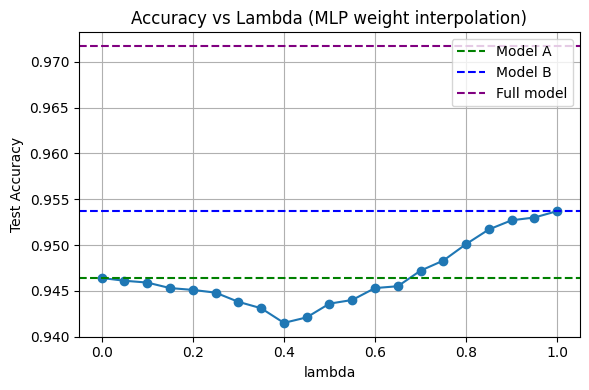

In [45]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()